# Benchmark of ML models

### Decision tree regressor

In [1]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from pickle import load
from tqdm import tqdm

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [48]:
# Read the best fit hyperparameters
file = open('../src/data_mining/trained_models/rf_model_tuned_v1.pkl', 'rb')
best_fit_model = load(file)
file.close()

ModuleNotFoundError: No module named 'pycaret'

In [2]:
# Taken from https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py

df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

rgr = DecisionTreeRegressor(random_state = 0)
path = rgr.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

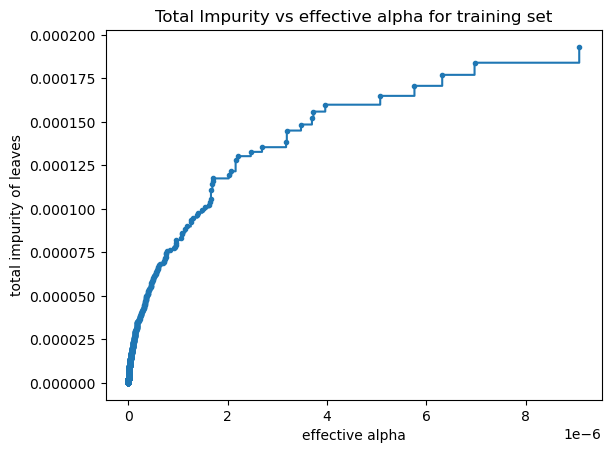

In [3]:
fig, ax = plt.subplots()
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", markersize = 3.0, drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

In [4]:
rgrs = []
for ccp_alpha in tqdm(ccp_alphas[1:], total = len(ccp_alphas[1:]), desc = "Training trees"):
    rgr = DecisionTreeRegressor(random_state = 0, 
                                ccp_alpha = ccp_alpha, 
                                criterion = 'squared_error', 
                                max_features = 0.8, 
                                min_samples_split = 0.00017239623972536324,
                                min_samples_leaf = 0.0006733944396699074,
                                splitter = 'best')
    rgr.fit(X_train, y_train)
    rgrs.append(rgr)
    
print("Number of nodes in the last tree is: {} with ccp_alpha: {}".format(rgrs[-1].tree_.node_count, ccp_alphas[-1]))

Training trees: 100%|██████████| 4528/4528 [25:11<00:00,  3.00it/s]

Number of nodes in the last tree is: 1 with ccp_alpha: 6.96303179756792e-05


In [5]:
total_sum = 0.0

for rgr in rgrs:
    total_sum += rgr.feature_importances_
    
# Compute the mean of the feature importances
total_sum = total_sum/len(total_sum)

In [12]:
corr = df.corr(method = 'spearman')

In [13]:
for column, correlation, importance in zip(df.columns[:-1], corr['UHI Index'].values[:-1], total_sum):
    print(column, correlation, importance)

gndvi_median_res100 -0.26960740029197466 0.8173319593362219
fs_median_res100 0.2837008754309153 0.20413953299449983
siwsi_median_res100 -0.24280627620865802 0.40708652439765985
si_median_res100 0.20226765685218298 1.8403807564394885
w_median_res100 -0.21816191047909567 0.4041240527546458
evi_median_res100 -0.17787421787852986 0.16800714618706467
B6_median_res100 0.10596795827905821 0.9223501431343691
gndvi_median_res250 -0.2193487371527983 0.6134710302794678
fs_median_res250 0.27077150335948813 0.2845307037147934
siwsi_median_res250 -0.23476482353140354 1.1465307499049096
ndmi_median_res250 -0.21439003704789072 0.4313937540116177
si_median_res250 0.1567314794410387 1.6959574443106384
w_median_res250 -0.3251936237594454 0.9268578893499154
evi_median_res250 -0.11001918994187013 1.3508771726200397
B2_median_res250 0.41637098864427635 0.20061868001616712
B5_median_res250 0.44410122140350244 0.24080359544426272
B6_median_res250 0.209294284833095 0.6667386993343052
B8_median_res250 0.0920172

Los que más suman son: LST, Polygon density y Air temperature at surface

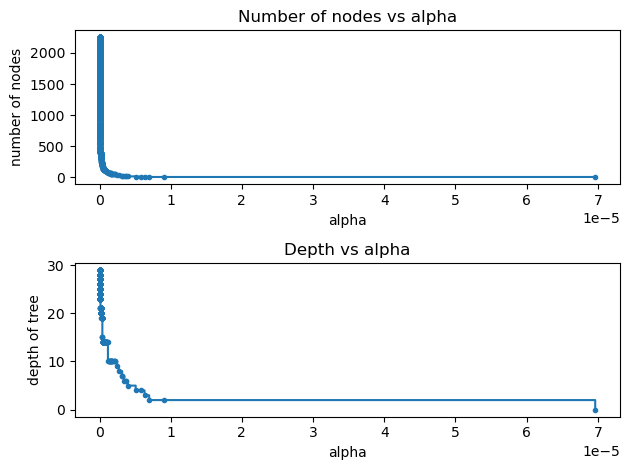

In [6]:
node_counts = [rgr.tree_.node_count for rgr in rgrs]
depth = [rgr.tree_.max_depth for rgr in rgrs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas[1:], node_counts, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")

ax[1].plot(ccp_alphas[1:], depth, marker = "o", markersize = 3.0, drawstyle = "steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

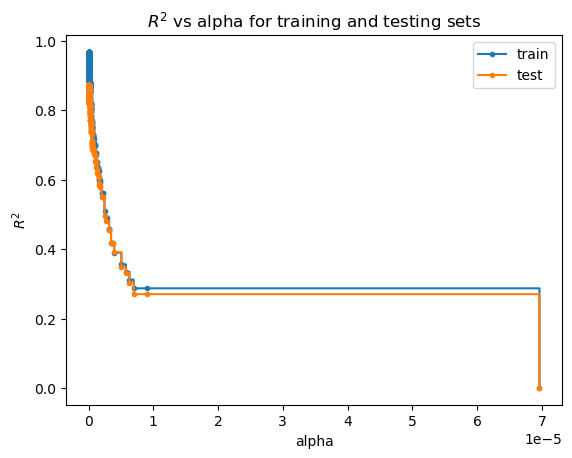

In [7]:
train_predictions = [rgr.predict(X_train) for rgr in rgrs]
test_predictions = [rgr.predict(X_test) for rgr in rgrs]

r2_train = [r2_score(y_train, y_pred) for y_pred in train_predictions]
r2_test = [r2_score(y_test, y_pred) for y_pred in test_predictions]

fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

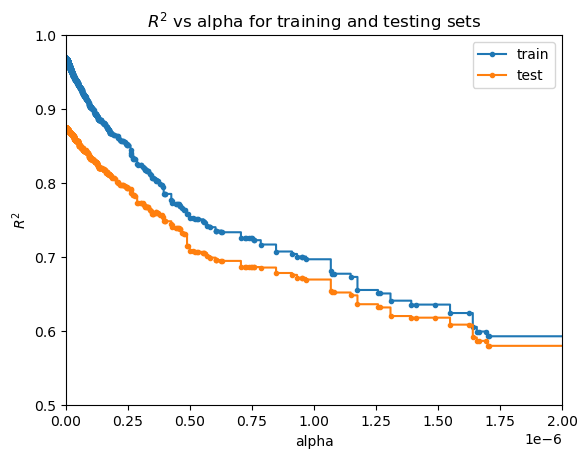

In [8]:
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs alpha for training and testing sets")
ax.plot(ccp_alphas[1:], r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(ccp_alphas[1:], r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.set_xlim(0.0, 0.2e-5)
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.show()

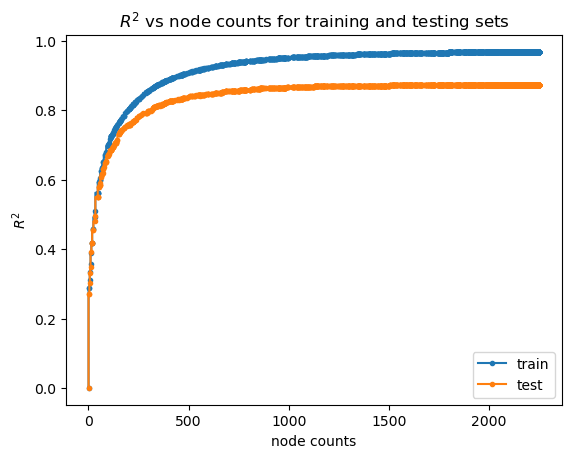

In [9]:
fig, ax = plt.subplots()
ax.set_xlabel("node counts")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs node counts for training and testing sets")
ax.plot(node_counts, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(node_counts, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

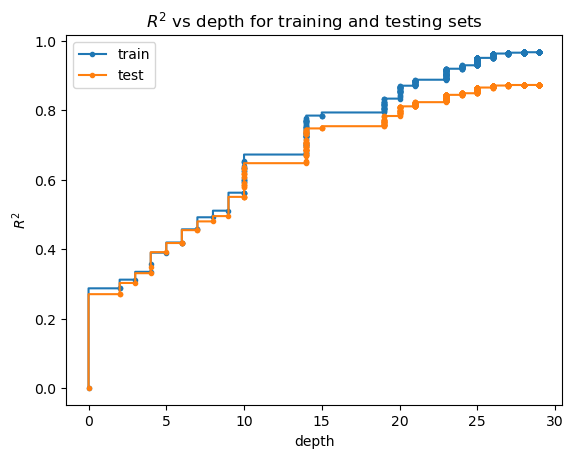

In [10]:
fig, ax = plt.subplots()
ax.set_xlabel("depth")
ax.set_ylabel("$R^{2}$")
ax.set_title("$R^{2}$ vs depth for training and testing sets")
ax.plot(depth, r2_train, marker="o", markersize = 3.0, label="train", drawstyle="steps-post")
ax.plot(depth, r2_test, marker="o", markersize = 3.0, label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [11]:
depth[1]

29

### Random forest regressor

In [222]:
# Packages
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import make_scorer
r2 = make_scorer(r2_score)
from sklearn.inspection import permutation_importance
from pandas import read_csv, Series
from numpy import std

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [227]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_corr_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Model
rfr = RandomForestRegressor(n_estimators = 256, 
                            criterion = 'poisson',
                            ccp_alpha = 5.932791367786729e-20, 
                            max_features = 0.7, 
                            max_leaf_nodes = 2205,
                            min_samples_split = 0.00017239623972536324,
                            min_samples_leaf = 0.0006733944396699074,
                            max_depth = 27,
                            random_state = 10)

In [228]:
# Fit the model
rfr.fit(X_train, y_train)

RandomForestRegressor(ccp_alpha=5.932791367786729e-20, criterion='poisson',
                      max_depth=27, max_features=0.7, max_leaf_nodes=2205,
                      min_samples_leaf=0.0006733944396699074,
                      min_samples_split=0.00017239623972536324,
                      n_estimators=256, random_state=10)

In [229]:
# Predict
train_predictions = rfr.predict(X_train.values)
test_predictions = rfr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


R^2 over training data: 0.973201946330755
R^2 over test data: 0.9341968611457923


c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [230]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = rfr.predict(X_test_super_cold.values)
test_predictions_cold = rfr.predict(X_test_cold.values)
test_predictions_mean = rfr.predict(X_test_mean.values)
test_predictions_hot = rfr.predict(X_test_hot.values)
test_predictions_super_hot = rfr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


R^2 over Super Cold test data: -2.6127576629830114. Number of datapoints in subdataset: 52
R^2 over Cold test data: 0.10969692803702435. Number of datapoints in subdataset: 436
R^2 over Mean test data: 0.8383194392956854. Number of datapoints in subdataset: 1883
R^2 over Hot test data: -0.006868704937460501. Number of datapoints in subdataset: 367
R^2 over Super Hot test data: -7.6082363406485936. Number of datapoints in subdataset: 70


In [231]:
# Compute importances
importances = rfr.feature_importances_

# Compute standard deviation for each feature importance
importances_std = std([tree.feature_importances_ for tree in rfr.estimators_], axis = 0)

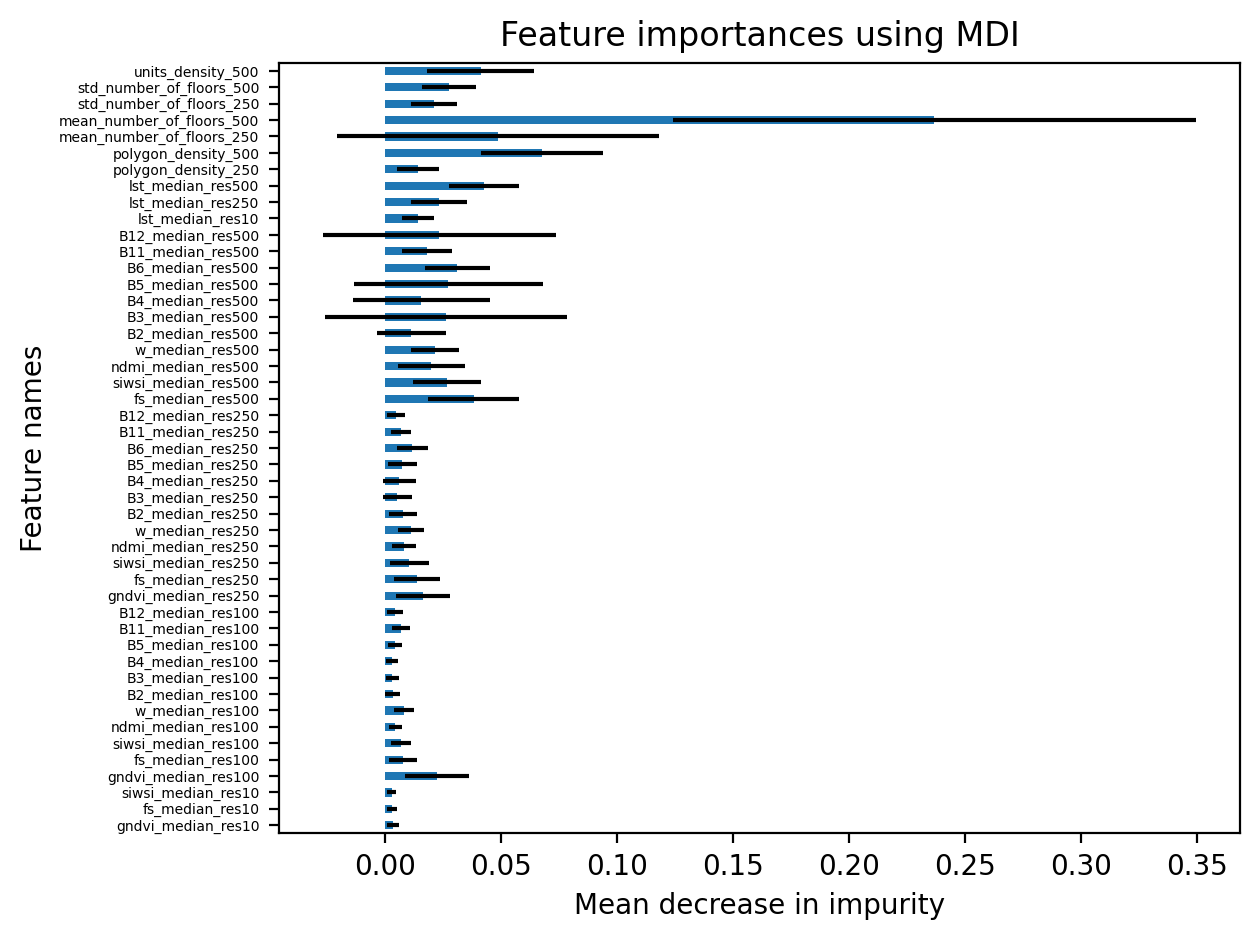

In [232]:
# Impurity-based importance plot
forest_importances = Series(importances, index = X_train.columns)

fig, ax = plt.subplots(1, 1, dpi = 200)
forest_importances.plot.barh(xerr = importances_std, ax = ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Feature names")
ax.set_xlabel("Mean decrease in impurity")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()

In [233]:
# Compute permutation importance
result = permutation_importance(rfr, X_test, y_test, scoring = r2, n_repeats = 10, random_state = 42)

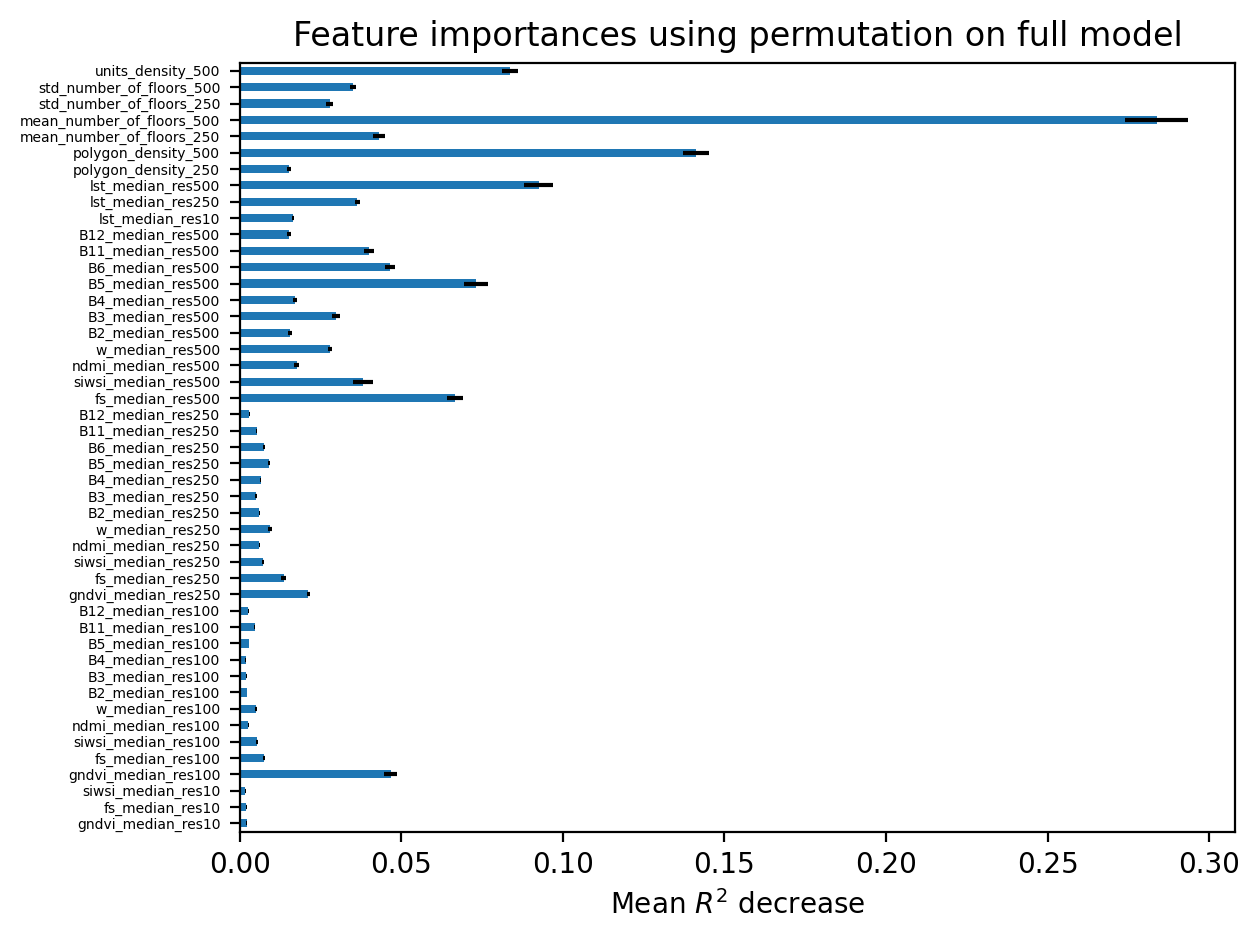

In [234]:
# Covert importances to Series object
forest_permutation_importances = Series(result.importances_mean, index = X_train.columns)

# Plot the importance ranking
fig, ax = plt.subplots(1, 1, dpi = 200)
forest_permutation_importances.plot.barh(xerr = result.importances_std, ax = ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_xlabel("Mean $R^{2}$ decrease")
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 5)
fig.tight_layout()
plt.show()

### XGBoost regressor

In [26]:
# Packages
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from xgboost import plot_importance
from sklearn.metrics import r2_score
from pandas import read_csv, concat
from numpy import logspace
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [27]:
# Dataset
df_1 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
df_1.rename(columns = {"UHI Index binned" : "UHI Index"}, inplace = True)
df_2 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_2.drop(columns = ['means_clusters'], inplace = True)
df = concat((df_1, df_2), axis = 0)
df.drop_duplicates(subset = df.columns[:-1], keep = 'last', inplace = True)
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# XGBoost Regressor
xgbr = XGBRegressor(nthread = -1, 
                    colsample_bylevel = 0.0041021679312702106,
                    colsample_bynode = 9.496153919454603e-05,
                    colsample_bytree = 0.507766346902615,
                    eta = 0.06846197227002367,
                    gamma = 8.336928029145515e-07,
                    max_depth = 15,
                    min_child_weight = 0.00010584940961770894,
                    reg_alpha = 0.00044107814104277964,
                    reg_lambda = 1.1242717718084416e-08,
                    subsample = 0.6863233496022993,
                    tree_method = 'exact',
                    random_state = 10)

In [28]:
# Train the model
xgbr.fit(X_train.values, y_train.values)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=0.0041021679312702106,
             colsample_bynode=9.496153919454603e-05,
             colsample_bytree=0.507766346902615, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.06846197227002367, eval_metric=None, feature_types=None,
             gamma=8.336928029145515e-07, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=15,
             max_leaves=None, min_child_weight=0.00010584940961770894,
             missing=nan, monotone_constraints=None, multi_strategy=None,
             n_estimators=None, n_jobs=None, nthread=-1, ...)

In [29]:
# Predict
train_predictions = xgbr.predict(X_train.values)
test_predictions = xgbr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9992544141329852
R^2 over test data: 0.9863949332770254


In [30]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = xgbr.predict(X_test_super_cold.values)
test_predictions_cold = xgbr.predict(X_test_cold.values)
test_predictions_mean = xgbr.predict(X_test_mean.values)
test_predictions_hot = xgbr.predict(X_test_hot.values)
test_predictions_super_hot = xgbr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: 0.8199364676031005. Number of datapoints in subdataset: 891
R^2 over Cold test data: 0.5910248284412631. Number of datapoints in subdataset: 1154
R^2 over Mean test data: 0.8697584736232535. Number of datapoints in subdataset: 2444
R^2 over Hot test data: 0.4736312141971334. Number of datapoints in subdataset: 1179
R^2 over Super Hot test data: 0.4783345909411485. Number of datapoints in subdataset: 1082


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

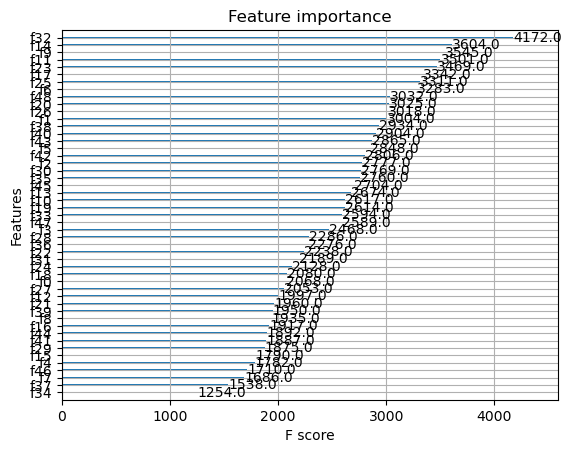

In [12]:
plot_importance(xgbr)

In [13]:
xgbr.feature_importances_*100.0

array([1.4493718 , 2.7135692 , 1.2215683 , 0.6181668 , 2.2478569 ,
       1.47533   , 0.6209917 , 0.91640997, 1.3965163 , 2.2191749 ,
       1.7433215 , 0.5685176 , 0.41500586, 0.90760124, 1.0265099 ,
       2.6294355 , 1.6692353 , 0.62248164, 0.7625041 , 1.0921186 ,
       1.9753479 , 2.4394815 , 0.43429238, 2.426502  , 3.0315948 ,
       2.392233  , 1.9506627 , 4.6939406 , 4.3991413 , 0.9013224 ,
       0.65145713, 0.14038078, 1.1460875 , 1.1525569 , 3.7775755 ,
       1.4580771 , 5.0354776 , 2.1299183 , 2.5108743 , 3.1360474 ,
       1.8619461 , 1.7738395 , 4.830135  , 6.2120633 , 3.8267798 ,
       3.0045848 , 4.7228403 , 0.7936612 , 0.87548757], dtype=float32)

In [14]:
# Set array of eta values
eta = logspace(-5, 0, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, eta_value in enumerate(eta):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.0041021679312702106,
                        colsample_bynode = 9.496153919454603e-05,
                        colsample_bytree = 0.507766346902615,
                        eta = eta_value,
                        gamma = 8.336928029145515e-07,
                        max_depth = 15,
                        min_child_weight = 0.00010584940961770894,
                        reg_alpha = 0.00044107814104277964,
                        reg_lambda = 1.1242717718084416e-08,
                        subsample = 0.6863233496022993,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

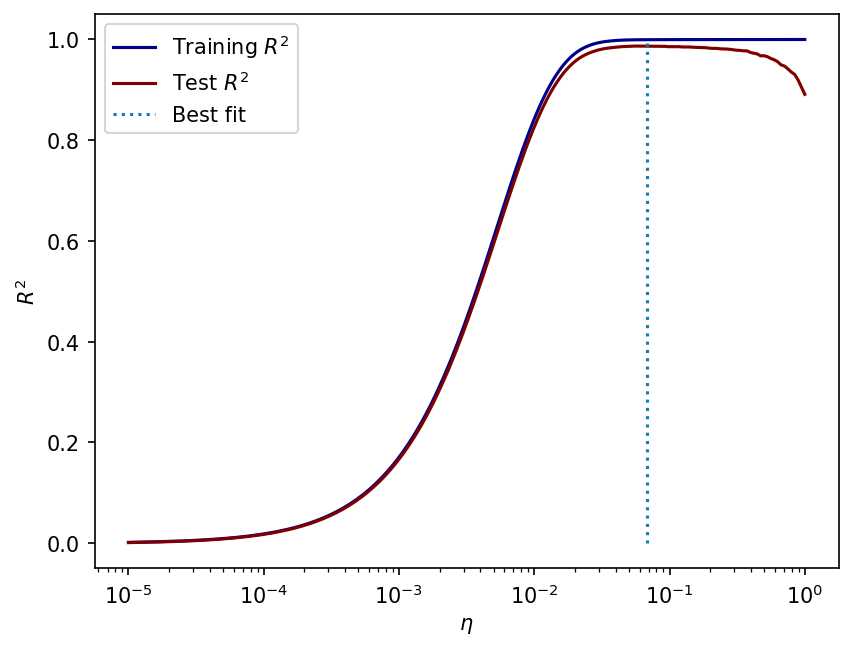

In [17]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(eta, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(eta, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.06846197227002367, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xlim(0.01, 0.1)
ax.set_xscale('log')
ax.set_xlabel('$\eta$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [18]:
# Set array of eta values
reg_lambda = logspace(-10, -4, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, lambda_value in enumerate(reg_lambda):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.0041021679312702106,
                        colsample_bynode = 9.496153919454603e-05,
                        colsample_bytree = 0.507766346902615,
                        eta = 0.06846197227002367,
                        gamma = 8.336928029145515e-07,
                        max_depth = 15,
                        min_child_weight = 0.00010584940961770894,
                        reg_alpha = 0.00044107814104277964,
                        reg_lambda = lambda_value,
                        subsample = 0.6863233496022993,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

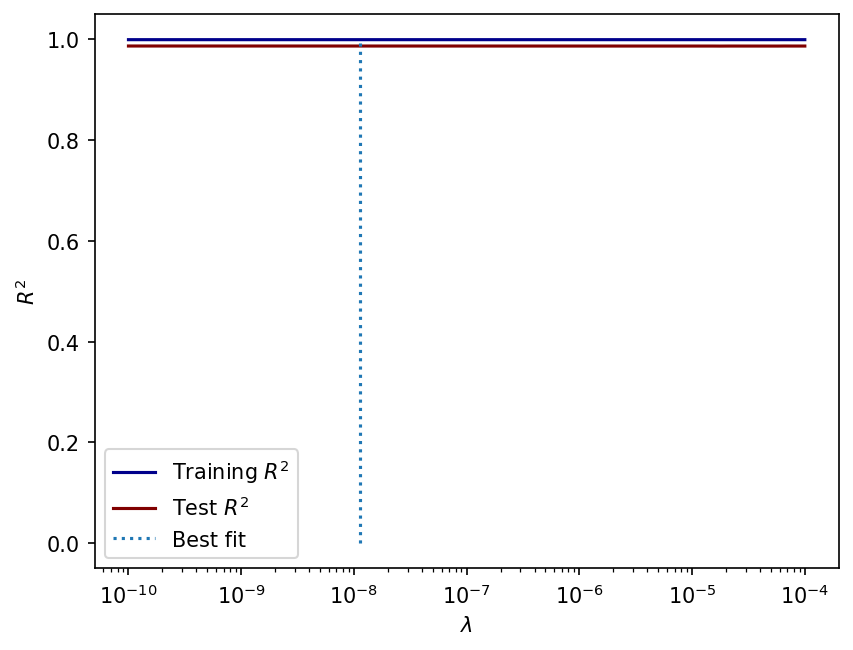

In [19]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_lambda, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_lambda, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1.1242717718084416e-08, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('$\lambda$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [20]:
# Set array of eta values
reg_alpha = logspace(-9, 0, 200)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, alpha_value in enumerate(reg_alpha):
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.0041021679312702106,
                        colsample_bynode = 9.496153919454603e-05,
                        colsample_bytree = 0.507766346902615,
                        eta = 0.06846197227002367,
                        gamma = 8.336928029145515e-07,
                        max_depth = 15,
                        min_child_weight = 0.00010584940961770894,
                        reg_alpha = alpha_value,
                        reg_lambda = 1.1242717718084416e-08,
                        subsample = 0.6863233496022993,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

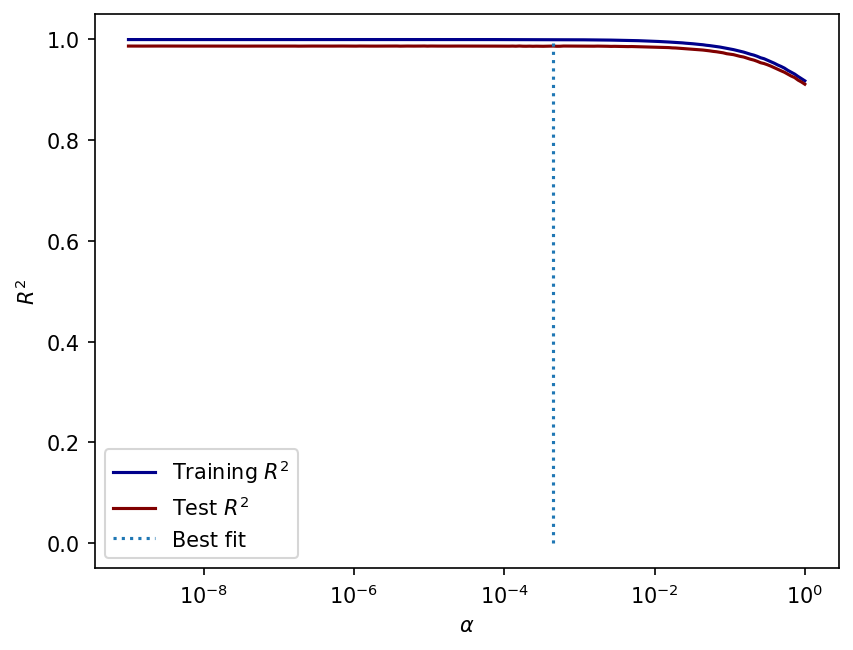

In [21]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(reg_alpha, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(reg_alpha, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(0.00044107814104277964, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [22]:
# Set array of depth values
depth = [i for i in range(1, 26, 1)]

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for depth_value in depth:
    # Set a new model
    xgbr = XGBRegressor(nthread = -1, 
                        colsample_bylevel = 0.0041021679312702106,
                        colsample_bynode = 9.496153919454603e-05,
                        colsample_bytree = 0.507766346902615,
                        eta = 0.06846197227002367,
                        gamma = 8.336928029145515e-07,
                        max_depth = depth_value,
                        min_child_weight = 0.00010584940961770894,
                        reg_alpha = 0.00044107814104277964,
                        reg_lambda = 1.1242717718084416e-08,
                        subsample = 0.6863233496022993,
                        tree_method = 'exact',
                        random_state = 10)
    
    # Train the model
    xgbr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = xgbr.predict(X_train.values)
    test_predictions = xgbr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(depth_value))

Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished


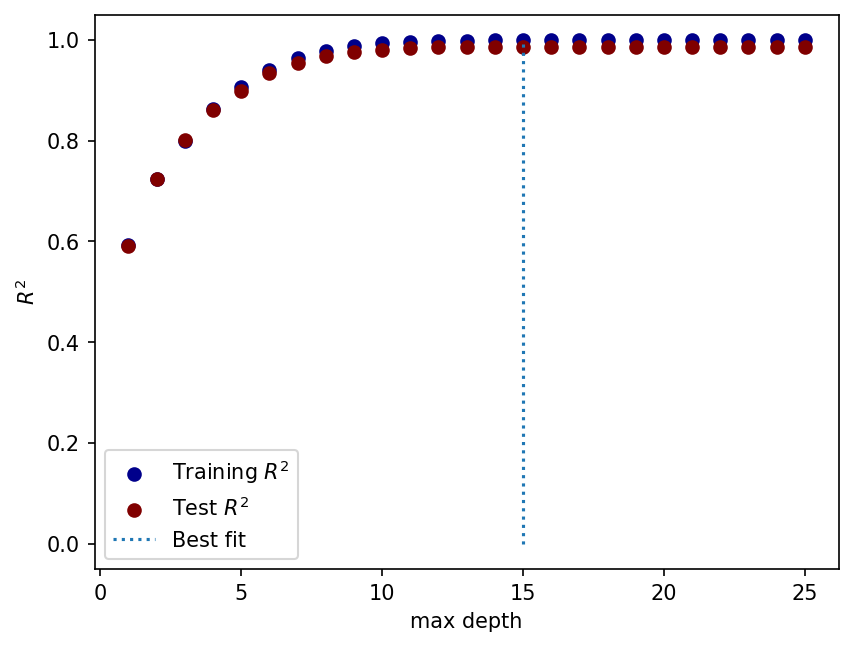

In [23]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.scatter(depth, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.scatter(depth, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(15, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xlabel('max depth')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

### KNN Regressor

In [16]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score
from pandas import read_csv, concat
from numpy import arange, int64
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [17]:
# Dataset
df_1 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
df_1.rename(columns = {"UHI Index binned" : "UHI Index"}, inplace = True)
df_2 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_2.drop(columns = ['means_clusters'], inplace = True)
df = concat((df_1, df_2), axis = 0)
df.drop_duplicates(subset = df.columns[:-1], keep = 'last', inplace = True)
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# KNN Regressor
"""knnr = KNeighborsRegressor(weights = 'distance',
                           n_neighbors = 194, 
                           leaf_size = 356,
                           algorithm = 'kd_tree')"""
knnr = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 2, 
                            p = 2, 
                            weights = 'distance')

In [18]:
# Train the model
knnr.fit(X_train.values, y_train.values)

KNeighborsRegressor(metric='manhattan', n_jobs=1, n_neighbors=2, p=1,
                    weights='distance')

In [19]:
# Predict
train_predictions = knnr.predict(X_train.values)
test_predictions = knnr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 1.0
R^2 over test data: 0.992925959756282


In [20]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = knnr.predict(X_test_super_cold.values)
test_predictions_cold = knnr.predict(X_test_cold.values)
test_predictions_mean = knnr.predict(X_test_mean.values)
test_predictions_hot = knnr.predict(X_test_hot.values)
test_predictions_super_hot = knnr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: 0.9898202278174032. Number of datapoints in subdataset: 891
R^2 over Cold test data: 0.8651469841188573. Number of datapoints in subdataset: 1154
R^2 over Mean test data: 0.9083089684674717. Number of datapoints in subdataset: 2444
R^2 over Hot test data: 0.6975093908704435. Number of datapoints in subdataset: 1179
R^2 over Super Hot test data: 0.9081532779549087. Number of datapoints in subdataset: 1082


In [267]:
# Set array of eta values
k = arange(1, 51, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, k_value in enumerate(k):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = 30, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = k_value, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

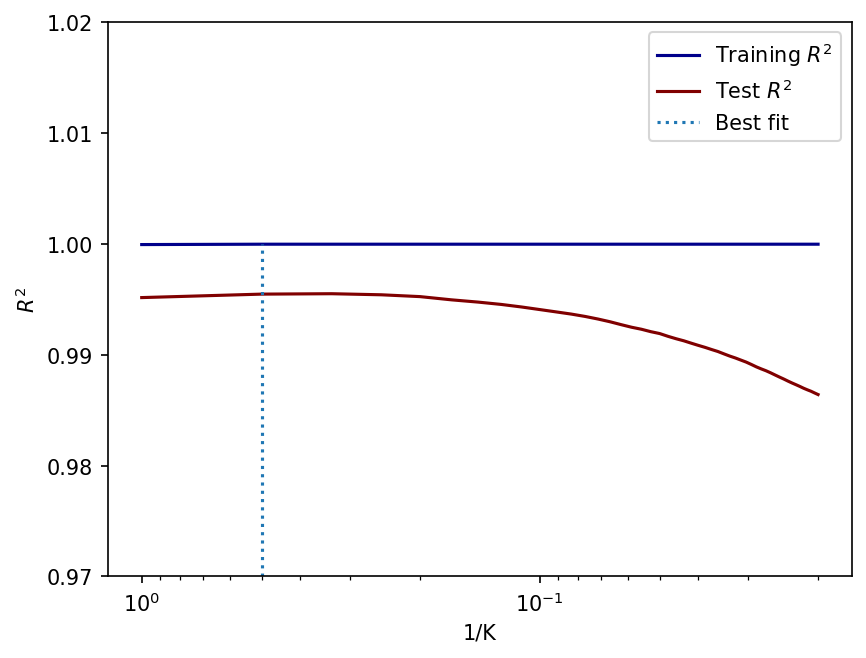

In [268]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(1/k, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(1/k, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1/2, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.invert_xaxis()
ax.set_xlabel('1/K')
ax.set_ylabel('$R^{2}$')
ax.set_ylim(0.97, 1.02)
ax.legend()
plt.show()

In [194]:
# Set array of eta values
leaf_size = arange(1, 201, 1, dtype = int64)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, leaf_value in enumerate(leaf_size):
    # Set a new model
    knnr = KNeighborsRegressor(algorithm = 'auto', 
                               leaf_size = leaf_value, 
                               metric = 'manhattan', 
                               metric_params = None, 
                               n_jobs = 1, 
                               n_neighbors = 3, 
                               p = 2, 
                               weights = 'distance')
    
    # Train the model
    knnr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = knnr.predict(X_train.values)
    test_predictions = knnr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

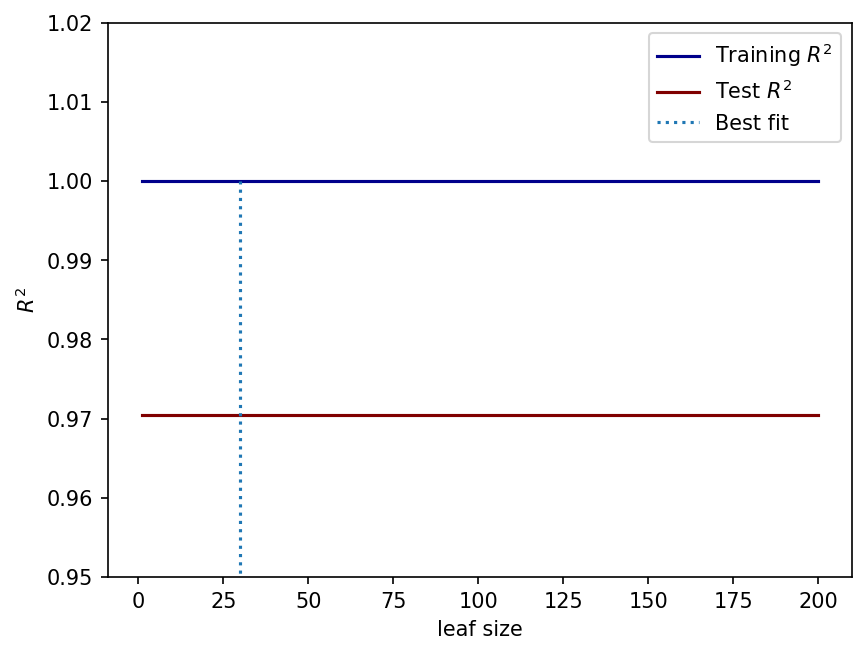

In [196]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(leaf_size, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(leaf_size, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(30, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xscale('log')
ax.set_xlabel('leaf size')
ax.set_ylabel('$R^{2}$')
ax.set_ylim(0.95, 1.02)
ax.legend()
plt.show()

### Ada Boost Regressor

In [279]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
from numpy import arange, logspace, int32
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [280]:
# Dataset
df_1 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
df_1.rename(columns = {"UHI Index binned" : "UHI Index"}, inplace = True)
df_2 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_2.drop(columns = ['means_clusters'], inplace = True)
df = concat((df_1, df_2), axis = 0)
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Ada Boost Regressor
abr = AdaBoostRegressor(estimator = KNeighborsRegressor(algorithm = 'auto', leaf_size = 30, metric = 'manhattan', metric_params = None, n_jobs = 1, n_neighbors = 2, p = 2, weights = 'distance'), random_state = 10)

In [281]:
# Train the model
abr.fit(X_train.values, y_train.values)

AdaBoostRegressor(estimator=KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                n_neighbors=2,
                                                weights='distance'),
                  random_state=10)

In [282]:
# Predict
train_predictions = abr.predict(X_train.values)
test_predictions = abr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9999643314776171
R^2 over test data: 0.9954303825935802


In [283]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = abr.predict(X_test_super_cold.values)
test_predictions_cold = abr.predict(X_test_cold.values)
test_predictions_mean = abr.predict(X_test_mean.values)
test_predictions_hot = abr.predict(X_test_hot.values)
test_predictions_super_hot = abr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: 0.9925146887771753. Number of datapoints in subdataset: 918
R^2 over Cold test data: 0.8644816882026521. Number of datapoints in subdataset: 1590
R^2 over Mean test data: 0.9589430757216111. Number of datapoints in subdataset: 4345
R^2 over Hot test data: 0.8602035280451218. Number of datapoints in subdataset: 1551
R^2 over Super Hot test data: 0.9708628620257085. Number of datapoints in subdataset: 1154


In [7]:
# Set array of learning rates values
learning_rate = logspace(-4, 0, 100)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, lr_value in enumerate(learning_rate):
    # Set a new model
    abr = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state = 0, max_depth = 5),
                            learning_rate = lr_value,
                            random_state = 10)
    
    # Train the model
    abr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = abr.predict(X_train.values)
    test_predictions = abr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

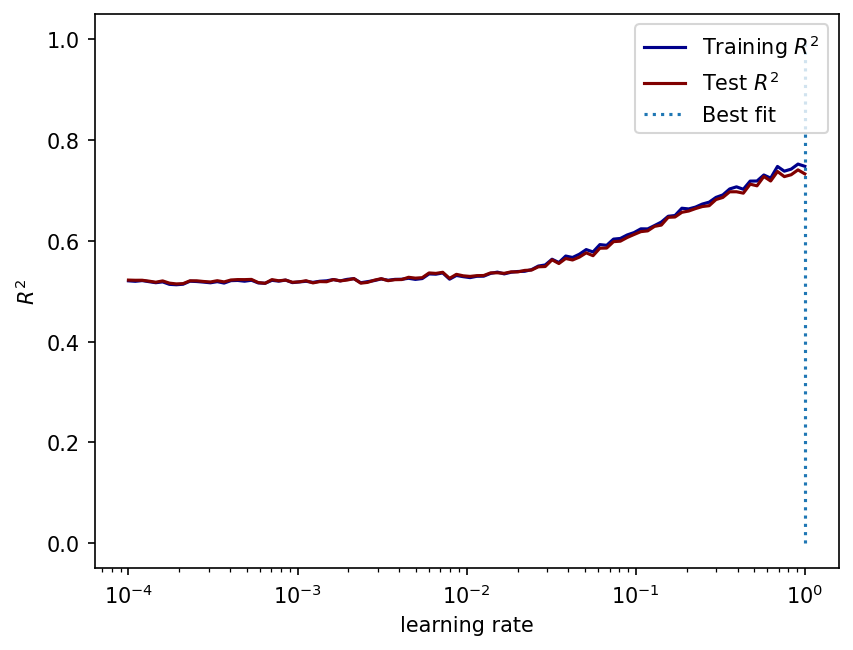

In [8]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(learning_rate, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(learning_rate, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(1.0, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
ax.set_xscale('log')
ax.set_xlabel('learning rate')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

In [11]:
# Set array of the number of estimators
n_estimators = arange(100, 201, 2, dtype = int32)

# Set R^2 arrays
r2_train_array = []
r2_test_array = []

for i, n in enumerate(n_estimators):
    # Set a new model
    abr = AdaBoostRegressor(estimator = DecisionTreeRegressor(random_state = 0, max_depth = 5),
                            n_estimators = n,
                            random_state = 10)
    
    # Train the model
    abr.fit(X_train.values, y_train.values)
    
    # Predict
    train_predictions = abr.predict(X_train.values)
    test_predictions = abr.predict(X_test.values)
    r2_train = r2_score(y_train, train_predictions)
    r2_test = r2_score(y_test, test_predictions)
    r2_train_array.append(r2_train)
    r2_test_array.append(r2_test)
    print("Prediction number {} finished".format(i))

Prediction number 0 finished
Prediction number 1 finished
Prediction number 2 finished
Prediction number 3 finished
Prediction number 4 finished
Prediction number 5 finished
Prediction number 6 finished
Prediction number 7 finished
Prediction number 8 finished
Prediction number 9 finished
Prediction number 10 finished
Prediction number 11 finished
Prediction number 12 finished
Prediction number 13 finished
Prediction number 14 finished
Prediction number 15 finished
Prediction number 16 finished
Prediction number 17 finished
Prediction number 18 finished
Prediction number 19 finished
Prediction number 20 finished
Prediction number 21 finished
Prediction number 22 finished
Prediction number 23 finished
Prediction number 24 finished
Prediction number 25 finished
Prediction number 26 finished
Prediction number 27 finished
Prediction number 28 finished
Prediction number 29 finished
Prediction number 30 finished
Prediction number 31 finished
Prediction number 32 finished
Prediction number 33

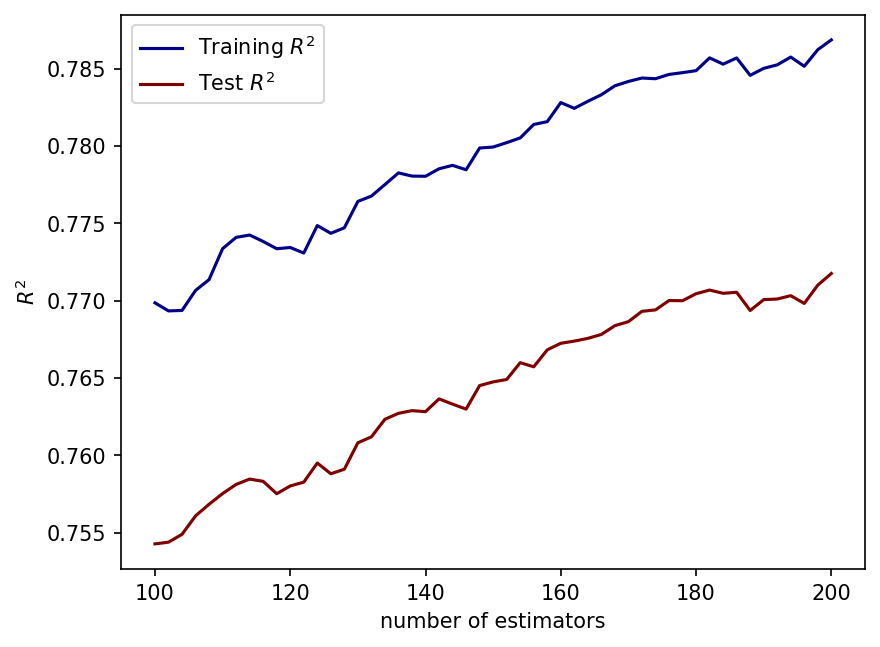

In [13]:
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.plot(n_estimators, r2_train_array, color = 'darkblue', label = 'Training $R^{2}$')
ax.plot(n_estimators, r2_test_array, color = 'maroon', label = 'Test $R^{2}$')
#ax.vlines(50, ymax = 1.0, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.set_xscale('log')
ax.set_xlabel('number of estimators')
ax.set_ylabel('$R^{2}$')
ax.legend()
plt.show()

### Lasso

In [1]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from pandas import read_csv
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject
Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [34]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Lasso
lasso_model = Lasso(alpha = 1.0e-6, max_iter = 20000)

In [35]:
# Train the model
lasso_model.fit(X_train.values, y_train.values)

c:\Users\santy\anaconda3\envs\env-ml\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.184e-02, tolerance: 2.213e-04
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=1e-06, max_iter=20000)

In [36]:
# Predict
train_predictions = lasso_model.predict(X_train.values)
test_predictions = lasso_model.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.44303436281738007
R^2 over test data: 0.4419395817008469


In [32]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = lasso_model.predict(X_test_super_cold.values)
test_predictions_cold = lasso_model.predict(X_test_cold.values)
test_predictions_mean = lasso_model.predict(X_test_mean.values)
test_predictions_hot = lasso_model.predict(X_test_hot.values)
test_predictions_super_hot = lasso_model.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: -44.731547177018065. Number of datapoints in subdataset: 52
R^2 over Cold test data: -8.408395983906829. Number of datapoints in subdataset: 436
R^2 over Mean test data: -0.1193559495079819. Number of datapoints in subdataset: 1883
R^2 over Hot test data: -11.256828033908006. Number of datapoints in subdataset: 367
R^2 over Super Hot test data: -56.777809807149126. Number of datapoints in subdataset: 70


In [33]:
lasso_model.coef_

array([-5.68282812e-03,  2.75450938e-04,  4.37407843e-03,  8.05074826e-04,
        1.01122657e-04, -8.08668563e-05, -9.21151021e-04,  4.34544870e-03,
       -1.34716652e-02, -1.44542912e-02,  3.07544138e-03, -1.52915947e-03,
       -2.53963106e-02,  1.20160026e-04,  2.65966821e-02,  1.78410599e-02,
       -2.99752530e-02,  1.76784891e-02,  3.63614262e-02, -5.04406599e-02,
        1.20027458e-03,  1.23617713e-02,  2.30051378e-02, -2.19049154e-02,
        3.11396782e-02, -1.70207892e-03, -2.36554684e-02, -2.39099155e-02,
        1.26658653e-02,  3.08019844e-04,  6.95548021e-02,  1.67391141e-02,
        5.69409996e-03, -8.38003582e-02, -3.06193758e-03,  3.85449551e-02,
       -8.21432919e-04,  1.93568739e-03,  7.49154929e-05, -2.03029154e-03,
        2.63843207e-03, -1.61958635e-03, -9.47442927e-04, -2.54810014e-04,
        3.06266555e-03,  2.94492291e-03, -4.23416172e-03, -2.82102066e-03,
        3.07796432e-04])

### Histogram-based Gradient Boosting Regression Tree

In [135]:
# Packages
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [136]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/interactions_datasets/interactions_reduced_smote_training_data.csv')
X = df.drop(columns = ['UHI Index binned'])
y = df['UHI Index binned']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# Hist GBR
hgbr = HistGradientBoostingRegressor(learning_rate = 0.5, max_iter = 100)

In [137]:
# Train the model
hgbr.fit(X_train.values, y_train.values)

HistGradientBoostingRegressor(learning_rate=0.5)

In [138]:
# Predict
train_predictions = hgbr.predict(X_train.values)
test_predictions = hgbr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9913266815613881
R^2 over test data: 0.9788287100098279


In [139]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = hgbr.predict(X_test_super_cold.values)
test_predictions_cold = hgbr.predict(X_test_cold.values)
test_predictions_mean = hgbr.predict(X_test_mean.values)
test_predictions_hot = hgbr.predict(X_test_hot.values)
test_predictions_super_hot = hgbr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: 0.599275154430617. Number of datapoints in subdataset: 922
R^2 over Cold test data: 0.3421279160705095. Number of datapoints in subdataset: 1241
R^2 over Mean test data: 0.7407855929963241. Number of datapoints in subdataset: 2309
R^2 over Hot test data: 0.3456627428326634. Number of datapoints in subdataset: 1222
R^2 over Super Hot test data: 0.5062547449402052. Number of datapoints in subdataset: 1063


### LightGBM

In [110]:
# Packages
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score
from pandas import read_csv
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [111]:
# Dataset
df = read_csv('../data/final_datasets/transformed_datasets/interactions_datasets/interactions_reduced_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# LightGBM
lgbm = LGBMRegressor()

In [112]:
# Train the model
lgbm.fit(X_train.values, y_train.values)

LGBMRegressor()

In [113]:
# Predict
train_predictions = lgbm.predict(X_train.values)
test_predictions = lgbm.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 0.9527831873209367
R^2 over test data: 0.9226117326600064


In [114]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = lgbm.predict(X_test_super_cold.values)
test_predictions_cold = lgbm.predict(X_test_cold.values)
test_predictions_mean = lgbm.predict(X_test_mean.values)
test_predictions_hot = lgbm.predict(X_test_hot.values)
test_predictions_super_hot = lgbm.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: -2.525096334385333. Number of datapoints in subdataset: 52
R^2 over Cold test data: -0.01949697348956092. Number of datapoints in subdataset: 436
R^2 over Mean test data: 0.7758458659125906. Number of datapoints in subdataset: 1883
R^2 over Hot test data: -0.14293971000907857. Number of datapoints in subdataset: 367
R^2 over Super Hot test data: -5.110425992444398. Number of datapoints in subdataset: 70


### Voting Regressor

In [32]:
# Packages
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.metrics import r2_score
from pandas import read_csv, concat

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [33]:
# Dataset
df_1 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_smote_training_data.csv')
df_1.rename(columns = {"UHI Index binned" : "UHI Index"}, inplace = True)
df_2 = read_csv('../data/final_datasets/transformed_datasets/transformed_reduced_training_data.csv')
df_2.drop(columns = ['means_clusters'], inplace = True)
df = concat((df_1, df_2), axis = 0)
df.drop_duplicates(subset = df.columns[:-1], keep = 'last', inplace = True)
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

knnr_1 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 1, 
                            p = 2, 
                            weights = 'distance')
knnr_2 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 2, 
                            p = 2, 
                            weights = 'distance')
knnr_3 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 3, 
                            p = 2, 
                            weights = 'distance')
knnr_4 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 4, 
                            p = 2, 
                            weights = 'distance')
knnr_5 = KNeighborsRegressor(algorithm = 'auto', 
                            leaf_size = 30, 
                            metric = 'manhattan', 
                            metric_params = None, 
                            n_jobs = 1, 
                            n_neighbors = 5, 
                            p = 2, 
                            weights = 'distance')
estimators = [('knnr_1', knnr_1), 
              ('knnr_2', knnr_2), 
              ('knnr_3', knnr_3), 
              ('knnr_4', knnr_4), 
              ('knnr_5', knnr_5)]
vr = VotingRegressor(estimators = estimators)

In [34]:
# Train the model
vr.fit(X_train.values, y_train.values)

VotingRegressor(estimators=[('knnr_1',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=1,
                                                 weights='distance')),
                            ('knnr_2',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=2,
                                                 weights='distance')),
                            ('knnr_3',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=3,
                                                 weights='distance')),
                            ('knnr_4',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 n_neighbors=4,
                                                 weights='distance')),
                            ('knnr_5',
                             KNeighborsRegressor(metric='manhattan', n_jobs=1,
                                                 weights='distance'))])

In [35]:
# Predict
train_predictions = vr.predict(X_train.values)
test_predictions = vr.predict(X_test.values)
r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)
print("R^2 over training data: {}".format(r2_train))
print("R^2 over test data: {}".format(r2_test))

R^2 over training data: 1.0
R^2 over test data: 0.9930985727511479


In [36]:
#sigma = y.values.std()
sigma = 0.016238

# Super cold
X_test_super_cold, y_test_super_cold = X_test[y_test < 1.0 - 2.0*sigma], y_test[y_test < 1.0 - 2.0*sigma]

# Cold
X_test_cold, y_test_cold = X_test[y_test < 1.0 - sigma], y_test[y_test < 1.0 - sigma]
X_test_cold, y_test_cold = X_test_cold[y_test_cold >= 1.0 - 2.0*sigma], y_test_cold[y_test_cold >= 1.0 - 2.0*sigma]

# Mean
X_test_mean, y_test_mean = X_test[y_test >= 1.0 - sigma], y_test[y_test >= 1.0 - sigma]
X_test_mean, y_test_mean = X_test_mean[y_test_mean < 1.0 + sigma], y_test_mean[y_test_mean < 1.0 + sigma]

# Hot
X_test_hot, y_test_hot = X_test[y_test >= 1.0 + sigma], y_test[y_test >= 1.0 + sigma]
X_test_hot, y_test_hot = X_test_hot[y_test_hot < 1.0 + 2.0*sigma], y_test_hot[y_test_hot < 1.0 + 2.0*sigma]

# Super hot
X_test_super_hot, y_test_super_hot = X_test[y_test >= 1.0 + 2.0*sigma], y_test[y_test >= 1.0 + 2.0*sigma]

# Predict
test_predictions_super_cold = vr.predict(X_test_super_cold.values)
test_predictions_cold = vr.predict(X_test_cold.values)
test_predictions_mean = vr.predict(X_test_mean.values)
test_predictions_hot = vr.predict(X_test_hot.values)
test_predictions_super_hot = vr.predict(X_test_super_hot.values)
r2_test_super_cold = r2_score(y_test_super_cold, test_predictions_super_cold)
r2_test_cold = r2_score(y_test_cold, test_predictions_cold)
r2_test_mean = r2_score(y_test_mean, test_predictions_mean)
r2_test_hot = r2_score(y_test_hot, test_predictions_hot)
r2_test_super_hot = r2_score(y_test_super_hot, test_predictions_super_hot)
print("R^2 over Super Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_cold, y_test_super_cold.size))
print("R^2 over Cold test data: {}. Number of datapoints in subdataset: {}".format(r2_test_cold, y_test_cold.size))
print("R^2 over Mean test data: {}. Number of datapoints in subdataset: {}".format(r2_test_mean, y_test_mean.size))
print("R^2 over Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_hot, y_test_hot.size))
print("R^2 over Super Hot test data: {}. Number of datapoints in subdataset: {}".format(r2_test_super_hot, y_test_super_hot.size))

R^2 over Super Cold test data: 0.9874212689773034. Number of datapoints in subdataset: 891
R^2 over Cold test data: 0.8729268220697246. Number of datapoints in subdataset: 1154
R^2 over Mean test data: 0.9113013953292032. Number of datapoints in subdataset: 2444
R^2 over Hot test data: 0.6957114706546601. Number of datapoints in subdataset: 1179
R^2 over Super Hot test data: 0.910470314841735. Number of datapoints in subdataset: 1082


In [172]:
df_to_reduce = read_csv('../data/final_datasets/transformed_datasets/transformed_test_data.csv')

In [173]:
df_to_reduce.drop(columns = ['B8A_median_res250',
'B8_median_res250',
'datt1_median_res10',
'B11_median_res10',
'B6_median_res100',
'B7_median_res10',
'evi_median_res250',
'evi_median_res500',
'B7_median_res250',
'air_temperature_at_surface [degC]',
'B8A_median_res10',
'gndvi_median_res500',
'B8_median_res10',
'w_median_res10',
'si_median_res10',
'population_density_500',
'population_density_250',
'si_median_res250',
'B8A_median_res500',
'B5_median_res10',
'B3_median_res10',
'B8_median_res500',
'B4_median_res10',
'B2_median_res10',
'evi_median_res100',
'B7_median_res500',
'B12_median_res10',
'units_density_250',
'ndmi_median_res10',
'si_median_res100',
'evi_median_res10'], inplace = True)

In [42]:
df_to_reduce.drop(columns = ['datt1_median_res10',
'B2_median_res10',
'B4_median_res10',
'ndmi_median_res10',
'si_median_res10',
'w_median_res10',
'B3_median_res10',
'B5_median_res10',
'B7_median_res10',
'B8_median_res10',
'evi_median_res10',
'B8A_median_res10',
'siwsi_median_res10',
'B4_median_res100',
'gndvi_median_res10',
'B11_median_res10',
'B12_median_res10',
'fs_median_res10',
'B3_median_res100',
'B5_median_res100',
'B2_median_res100',
'B3_median_res250',
'ndmi_median_res100',
'B12_median_res100',
'B12_median_res250',
'B4_median_res250',
'B7_median_res250',
'B11_median_res100',
'siwsi_median_res100',
'fs_median_res100',
'B6_median_res100',
'B2_median_res250',
'evi_median_res100',
'B11_median_res250',
'B8_median_res250',
'ndmi_median_res250',
'B6_median_res250',
'B5_median_res250',
'B2_median_res500'], inplace = True)

In [174]:
df_to_reduce.to_csv('../data/final_datasets/transformed_datasets/transformed_reduced_corr_test_data.csv', index = False)